# Advanced NLP Tasks

In [1]:
# Install if needed:
!pip install nltk scikit-learn gensim wordcloud textstat

import nltk
for p in ['wordnet','omw-1.4','punkt','punkt_tab','stopwords']:
    nltk.download(p)

from nltk.corpus import wordnet as wn


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 349.5 kB/s eta 0:00:05
   ---------- ----------------------------- 0.5/2.1 MB 349.5 kB/s eta 0:00:05
   ---------- --

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\naksh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\naksh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\naksh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\naksh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\naksh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Find synonyms

In [ ]:
syn=wn.synsets('happy');
print(set(l.name() for s in syn for l in s.lemmas()))

{'well-chosen', 'happy', 'glad', 'felicitous'}


## Find antonyms

In [3]:
ants=[]
for s in wn.synsets('happy'):
    for l in s.lemmas():
        if l.antonyms(): ants.append(l.antonyms()[0].name())
print(set(ants))

{'unhappy'}


## Sentence similarity

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
s=['I love NLP','I enjoy NLP']
X=TfidfVectorizer().fit_transform(s);print(cosine_similarity(X)[0,1])

0.33609692727625756


## Cosine similarity

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
X=CountVectorizer().fit_transform(['cat dog','cat fish']);print(cosine_similarity(X)[0,1])

0.4999999999999999


## Word2Vec similar words

In [6]:
from gensim.models import Word2Vec
sent=[['cat','dog','pet'],['dog','bark'],['cat','meow']]
m=Word2Vec(sent,vector_size=20,min_count=1,workers=1);print(m.wv.most_similar('cat'))

[('bark', 0.1523708701133728), ('dog', 0.05017898604273796), ('meow', -0.11861518025398254), ('pet', -0.17812974750995636)]


## Nearest neighbors

In [7]:
print(m.wv.most_similar('dog'))

[('bark', 0.05595850199460983), ('cat', 0.050178974866867065), ('pet', -0.06502574682235718), ('meow', -0.2928890585899353)]


## Word cloud

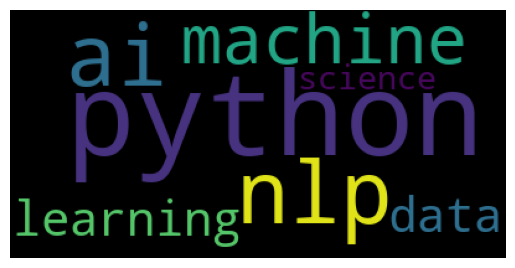

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text='python python nlp ai machine learning data science'
wc=WordCloud().generate(text)
plt.imshow(wc)
plt.axis('off')
plt.show()

## Keywords TFIDF

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
text=['python is easy and powerful']
t=TfidfVectorizer()
X=t.fit_transform(text)
print(t.get_feature_names_out())

['and' 'easy' 'is' 'powerful' 'python']


## Rank keywords

In [19]:
import numpy as np
scores=X.toarray()[0]
idx=np.argsort(scores)[::-1]
for i in idx: 
    print(t.get_feature_names_out()[i],scores[i])

python 0.4472135954999579
powerful 0.4472135954999579
is 0.4472135954999579
easy 0.4472135954999579
and 0.4472135954999579


## Readability

In [11]:
import textstat
print(textstat.flesch_reading_ease('Python is easy to learn.'))

83.32000000000004


## Count syllables

In [12]:
import textstat
print(textstat.syllable_count('processing'))

3


## Out of vocabulary

In [ ]:
vocab={'python','nlp','data'}
text='python ai deep learning'.split();
print([w for w in text if w not in vocab])

['ai', 'deep', 'learning']


## Document similarity

In [22]:
docs=['I love python','I enjoy python']
X=TfidfVectorizer().fit_transform(docs)
print(cosine_similarity(X)[0,1])

0.33609692727625756


## Extractive summary

In [15]:
text='Python is popular. It is easy to learn. It is used in AI.'
print('. '.join(text.split('. ')[:2]))

Python is popular. It is easy to learn


## Complete NLP pipeline

In [ ]:
import string
from sklearn.feature_extraction.text import CountVectorizer
text='Hello, World! NLP is fun.'
clean=text.lower().translate(str.maketrans('','',string.punctuation));tokens=clean.split();X=CountVectorizer().fit_transform([' '.join(tokens)]);print(tokens);print(X.toarray())

SyntaxError: invalid syntax (3441683636.py, line 4)